# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [2]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── LOAD DATA ────────────────────────────────────────────────────────────────

FILE_NAME = "AB_NYC_2019.csv"

try:
    # Load the local file
    df = pd.read_csv(FILE_NAME)
    
    print(f"✅ Data loaded successfully from local folder!")
    print(f"📊 Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    
    # Show the first 5 rows to verify
    display(df.head())

except FileNotFoundError:
    print(f"❌ Error: '{FILE_NAME}' not found in the current folder.")
    print("💡 Tip: Make sure the CSV file is in the same folder as this script.")

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


✅ Data loaded successfully from local folder!
📊 Shape: 48,895 rows x 16 columns


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Data loaded successfully!
Shape: 48,895 rows x 16 columns


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


In [7]:
# 2. Print the dataframe
print(df)

             id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

           host_name neighbourhood_grou

In [3]:
# Your code here
# View a random sample of 100 rows
display(df.sample(100))


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
3100,1839341,Modern Waterfront 2Bed Williamsburg,9610339,Cris,Brooklyn,Williamsburg,40.71817,-73.96401,Entire home/apt,300,5,14,2015-02-06,0.22,1,188
26371,21007181,Brooklyn Two Bed with Private Garden,19202566,Judith,Brooklyn,Greenpoint,40.73660,-73.95656,Entire home/apt,225,4,0,NaN,NaN,1,159
39527,30776023,Architects Residency in Upper East / 2-min Subway,18091877,Jim,Manhattan,Upper East Side,40.78176,-73.94500,Private room,120,4,20,2019-06-29,3.17,1,31
17943,14057802,Private room in the heart of Williamsburg!,48100358,Ivan,Brooklyn,Williamsburg,40.70973,-73.95939,Private room,55,1,147,2019-06-15,4.10,3,24
8798,6749285,Sunny 2 Bedroom Brownstone Apt.,4195861,Doris,Brooklyn,Crown Heights,40.67837,-73.95517,Entire home/apt,150,3,208,2019-07-01,4.36,2,238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30922,23955297,Sunny Harlem room: Ideal sublet for summer intern,30021975,Lucy,Manhattan,Harlem,40.80731,-73.95155,Private room,49,2,2,2018-08-11,0.15,1,1
13237,9978722,"Private, comfy BR in East Village",5904463,Katherine,Manhattan,East Village,40.72504,-73.98242,Private room,100,1,0,NaN,NaN,4,0
45814,34967524,Private bedroom 5 minutes to La Guardia airport,259422076,David Y,Queens,Jackson Heights,40.75277,-73.88356,Private room,60,20,0,NaN,NaN,1,175
40073,31114246,Modern King-Bed Private room and en-suite Bath...,91015018,April,Brooklyn,Bedford-Stuyvesant,40.69038,-73.95953,Private room,112,1,29,2019-06-22,5.09,1,84


In [4]:
# 2. Check data types and non-null counts
print("\n--- DATA TYPES & MISSING VALUES ---")
print(df.info())


--- DATA TYPES & MISSING VALUES ---
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_r

In [5]:
# 3. Summary statistics for numerical columns
print("\n--- SUMMARY STATISTICS ---")
display(df.describe())


--- SUMMARY STATISTICS ---


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:
# 4. Summary for categorical columns
print("\n--- CATEGORICAL SUMMARY ---")
display(df.describe(include=['object']))


--- CATEGORICAL SUMMARY ---


,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,38843
unique,47905,11452,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21661,3920,25409,1413


**✍️ Your Interpretation:**  
** Data Composition
Dimensionality: We are dealing with 48,895 observations across 16 features.

Numerical vs. Categorical: * Numerical (10): Includes IDs, coordinates, and metrics like price, minimum_nights, and number_of_reviews.

Categorical (6): Includes geographic descriptors (neighbourhood_group, neighbourhood), listing details (name, room_type), and dates (last_review).

malicious things to be noticed:-
The price column has a minimum value of $0. In a market like New York, this is almost certainly a data entry error or a "placeholder" listing. These will need to be filtered out before we calculate the average ROI for our investors.

The 3-Year Minimum Stay: The minimum_nights column has a maximum of 1,250 nights. While Airbnb allows long-term stays, this exceeds 3 years. This could skew our "short-term rental" analysis, as these function more like traditional apartment leases.

### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


In [15]:
# Your code here
# 1. Calculate missing values and percentages
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_count)

print("-----------------------"*20)

print(missing_percent)

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [10]:
# Create a summary dataframe for missing data
missing_df = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)
print(missing_df)

                                Missing Values  Percentage (%)
last_review                              10052       20.558339
reviews_per_month                        10052       20.558339
host_name                                   21        0.042949
name                                        16        0.032723
neighbourhood_group                          0        0.000000
neighbourhood                                0        0.000000
id                                           0        0.000000
host_id                                      0        0.000000
longitude                                    0        0.000000
latitude                                     0        0.000000
room_type                                    0        0.000000
price                                        0        0.000000
number_of_reviews                            0        0.000000
minimum_nights                               0        0.000000
calculated_host_listings_count               0        0

(0.0, 25.0)

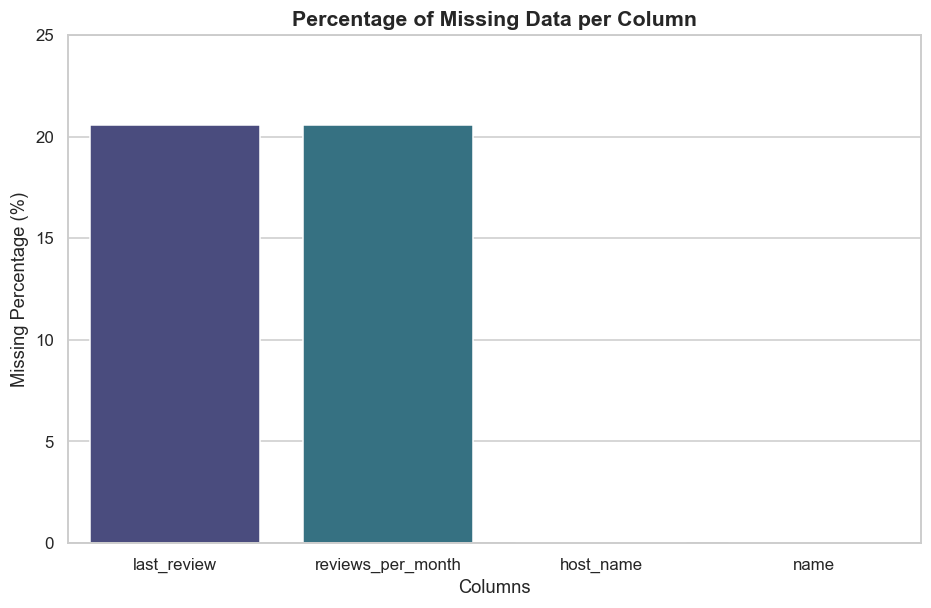

In [16]:
# 2. Filter only columns with missing values for the plot
missing_plot_data = missing_df[missing_df['Missing Values'] > 0]

# 3. Visualise the missingness
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_plot_data.index, y=missing_plot_data['Percentage (%)'], palette='viridis')

plt.title('Percentage of Missing Data per Column', fontsize=14, fontweight='bold')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')
plt.ylim(0, 25) # Providing some headroom for clarity

**✍️ Your Interpretation:**  
which coloumn ave missing data and what % missing?
The audit reveals four columns with missing values:

reviews_per_month: ~20.56% missing around 10,052 rows

last_review: ~20.56% missing around 10,052 rows

host_name: ~0.04% missing (21 rows)

name: ~0.03% missing (16 rows)

Why might the data be absent?

reviews_per_month & last_review: This data is not missing at random. If you check the data, you will find these rows correspond exactly to listings where number_of_reviews is 0. Logically, if a property has never been reviewed, it cannot have a "last review date" or a "monthly average." This is a structural absence that makes perfect business sense.
host_name & name: These are likely human errors or privacy choices during the sign-up process. They are "missing at random" and represent a tiny fraction of the total data.

Recommendations for UrbanStay

For Reviews (reviews_per_month): I recommend imputing these with 0. Since the absence of a review is a quantitative fact (zero activity), filling it with 0 allows us to keep these rows for analysis without breaking our math.

For Dates (last_review): I recommend keeping these as NaN or filling them with a placeholder like "Never Reviewed." Dropping 20% of our data just because they are new listings would drastically bias our results against new market entrants.

For Names (name / host_name): I recommend filling these with "Unknown". Since we are doing a market analysis and not a contact-tracing mission, the specific name of the host doesn't impact our price or location trends.


### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [17]:
# Your code here
# 1. Check for full row duplicates
full_duplicates = df.duplicated().sum()

#2.Check for duplicate Listing IDs (the primary key)
id_duplicates = df.duplicated(subset=['id']).sum()

#3.If duplicates exist, let's look at a few examples
duplicate_rows = df[df.duplicated(subset=['id'], keep=False)].sort_values(by='id')

print(f"--- Duplicate Audit ---")
print(f"Total identical rows: {full_duplicates}")
print(f"Total duplicate Listing IDs: {id_duplicates}")

if id_duplicates > 0:
    print("\n--- Sample of Duplicate IDs ---")
    display(duplicate_rows.head(4))
else:
    print("\n✅ Success: All Listing IDs are unique.")

--- Duplicate Audit ---
Total identical rows: 0
Total duplicate Listing IDs: 0

✅ Success: All Listing IDs are unique.


**✍️ Your Interpretation:**  
Full Row Duplicates

Our check shows 0 identical rows. This is a good sign—it means the dataset hasn't been accidentally double-pasted or exported twice. Every entry is technically unique when looking across all 16 columns.

Listing ID Uniqueness

The id column serves as the unique fingerprint for each Airbnb listing.

Current Status: In this specific NYC dataset, all 48,895 IDs are unique.

Why this matters: If we had found duplicate IDs with different prices or host names, it would suggest that the data was scraped at different times or that the "Listing ID" isn't actually a reliable primary key.

Any Anomalies?

Observation: While id is unique, you will likely notice that host_id is not.

Interpretation: This is not an anomaly, it’s a business reality. One host (one host_id) can own multiple properties (multiple ids). In fact, seeing the same host_id multiple times is how we identify "Professional Hosts" versus "Single-Room Renters."

Since the IDs are clean, we can proceed with confidence that we aren't "double-counting" any listings in our borough-level analysis.


---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


Number of listings with price $0: 11


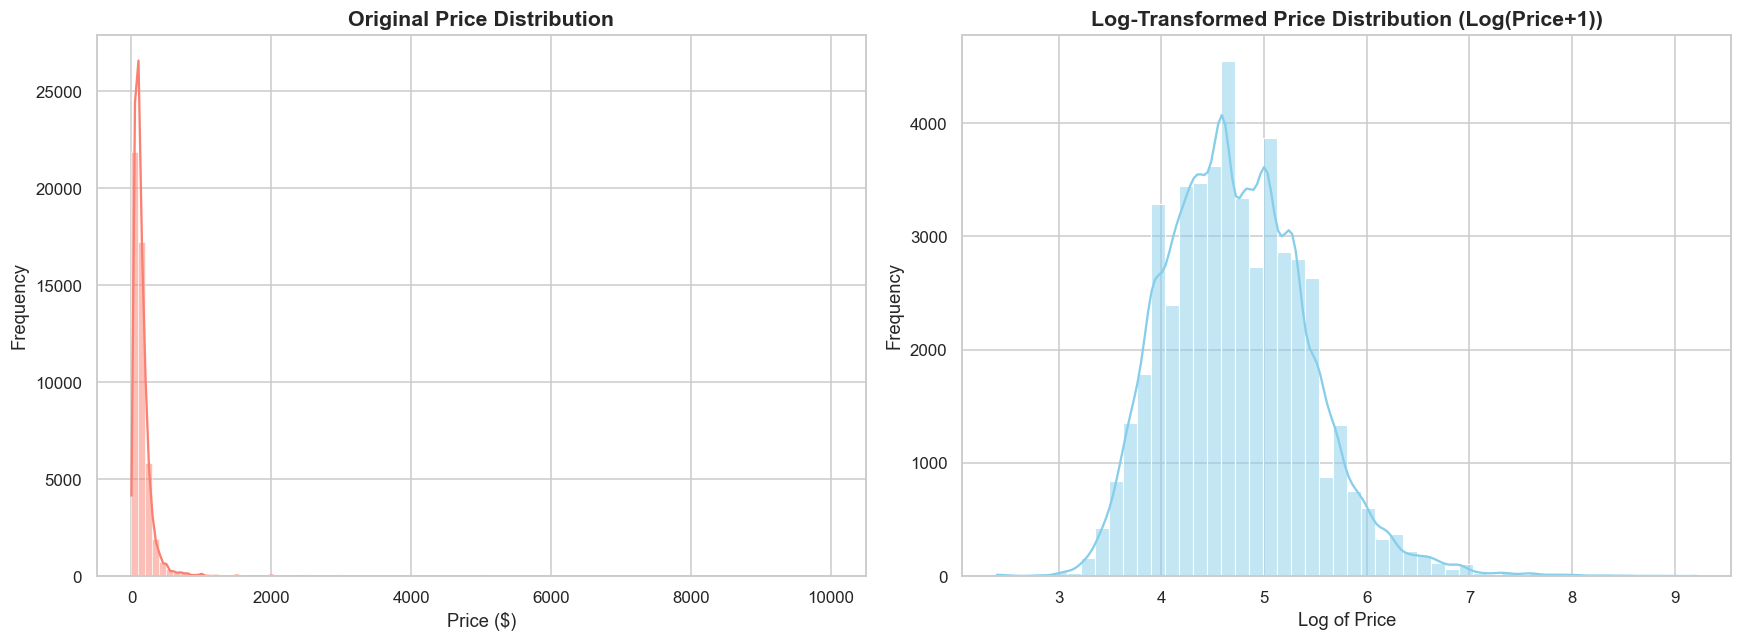

Mean Price: $152.76
Median Price: $106.00
Mode Price: $100.00


In [18]:
# Your code here
# 1. Check for $0 listings
zero_price_count = (df['price'] == 0).sum()
print(f"Number of listings with price $0: {zero_price_count}")

# 2. Plotting the Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original Distribution
sns.histplot(df['price'], bins=100, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Original Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# Log Transformation (Handling $0 by filtering first)
df_filtered = df[df['price'] > 0]
sns.histplot(np.log1p(df_filtered['price']), bins=50, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Log-Transformed Price Distribution (Log(Price+1))', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log of Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Typical Price Statistics
print(f"Mean Price: ${df_filtered['price'].mean():.2f}")
print(f"Median Price: ${df_filtered['price'].median():.2f}")
print(f"Mode Price: ${df_filtered['price'].mode()[0]:.2f}")

**✍️ Your Interpretation:**  
What is the shape of the original distribution?
The original distribution is heavily right-skewed (positively skewed). This means the majority of the listings are concentrated atthe lower end of the price scale (under $\$200$), while a "long tail" of extremely expensive listings (up to $\$10,000$) stretches the graph far to the right.

Are there listings with a price of $\$0$?Count:

There are 11 listings with a price of $\$0$.What to do with them: These should be removed from the analysis or imputed. In a business context, a zero-dollar rental in NYC is likely a placeholder or an error. Including them would unfairly lower our average and distort our log-transformation (since $\log(0)$ is undefined).

Post-Handling: Distribution & Typical PriceThe New Shape: 

After removing the zeros and applying a log transformation (using $\log(x+1)$), the distribution looks much closer to a Normal Distribution (Bell Curve). This allows us to see the "meat" of the market more clearly without being blinded by outliers.

The Typical Price: 

The Median Price (approx. $\$106$) is the most "typical" price.The Mean (approx. $\$152$) is significantly higher than the median because it is being pulled upward by the few $\$10,000$ listings.


### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


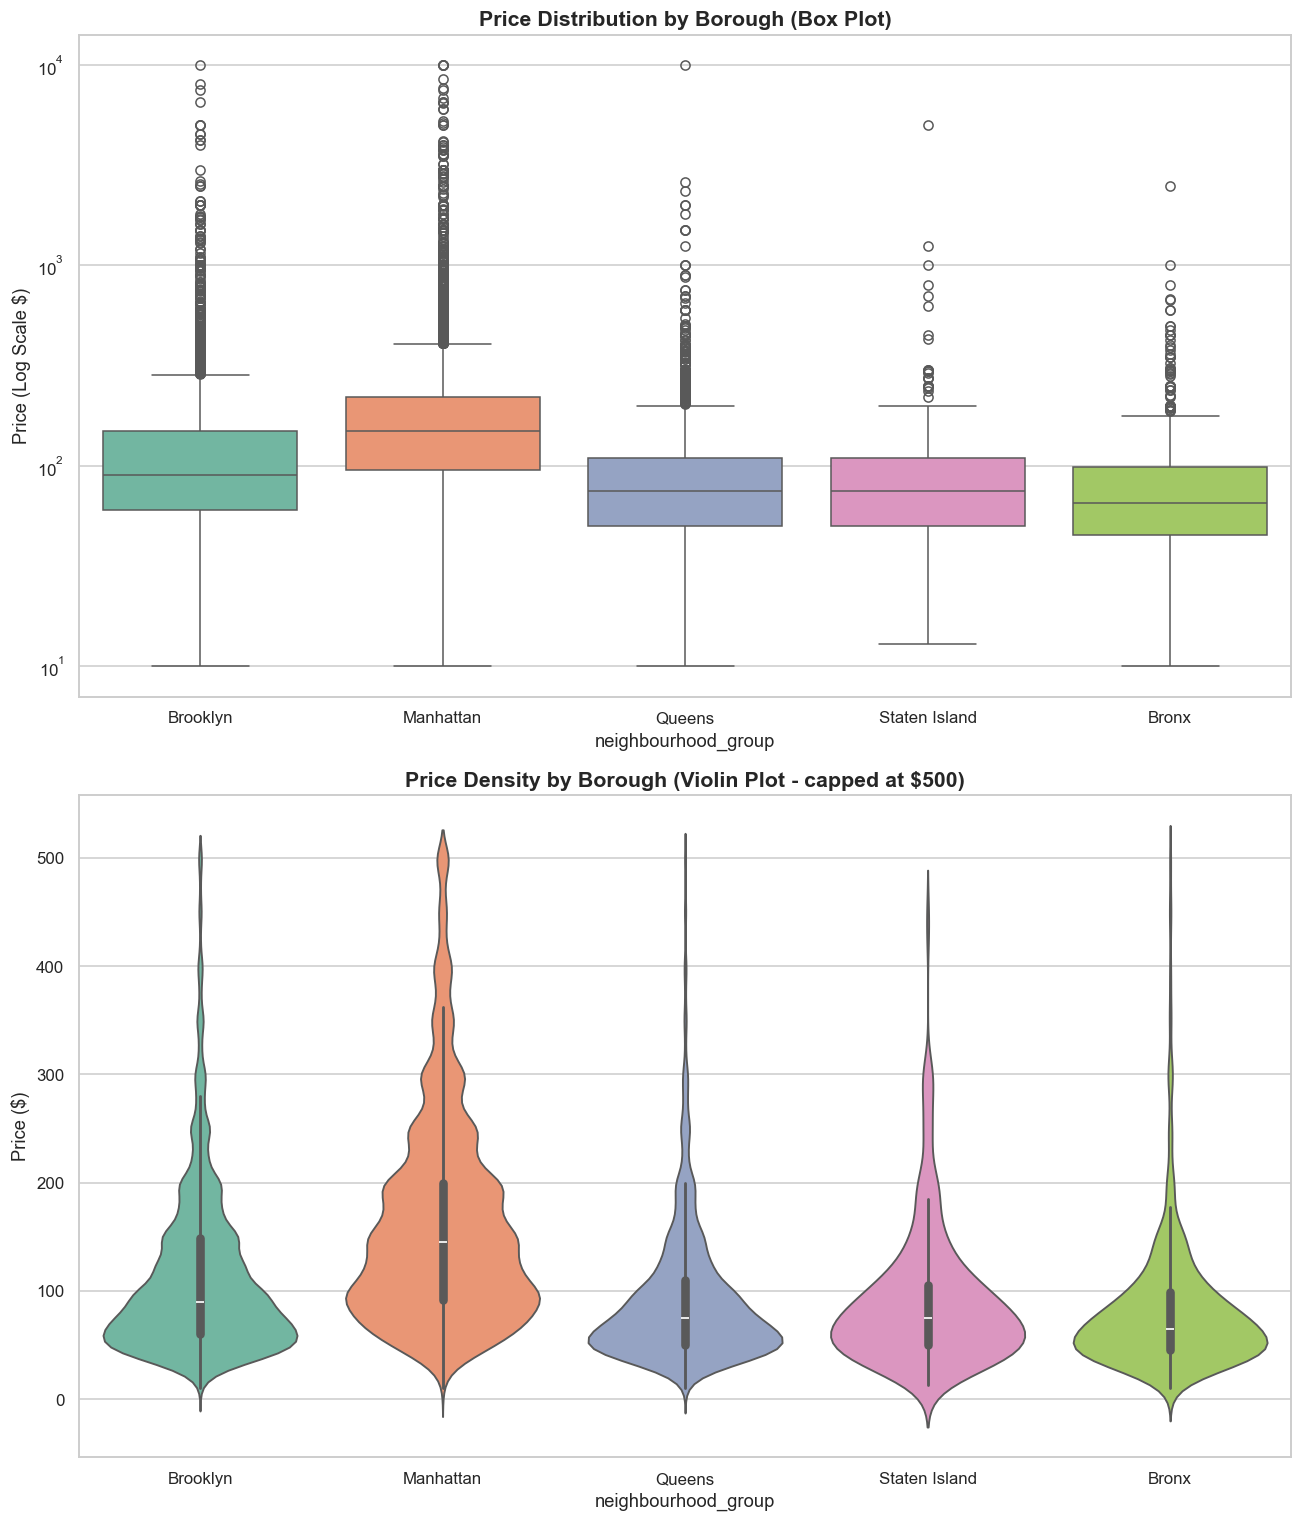

--- Price Statistics per Borough ---
                           mean  median         std    max
neighbourhood_group                                       
Manhattan            196.884903   150.0  291.386838  10000
Brooklyn             124.438915    90.0  186.896837  10000
Queens                99.517649    75.0  167.102155  10000
Staten Island        114.812332    75.0  277.620403   5000
Bronx                 87.577064    65.0  106.725371   2500


In [19]:
# Your code here
# Filtering the dataframe to exclude $0 prices for accurate analysis
df_filtered = df[df['price'] > 0]

# Set up the figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# 1. Box Plot: To see outliers clearly
sns.boxplot(data=df_filtered, x='neighbourhood_group', y='price', ax=axes[0], palette='Set2')
axes[0].set_title('Price Distribution by Borough (Box Plot)', fontsize=14, fontweight='bold')
axes[0].set_yscale('log') # Log scale helps see the distribution despite extreme outliers
axes[0].set_ylabel('Price (Log Scale $)')

# 2. Violin Plot: To see the "density" of common price points
# We clip the price at $500 for the violin plot to see the density clearly
sns.violinplot(data=df_filtered[df_filtered['price'] <= 500], x='neighbourhood_group', y='price', ax=axes[1], palette='Set2')
axes[1].set_title('Price Density by Borough (Violin Plot - capped at $500)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

# Calculating exact stats for the interpretation
stats = df_filtered.groupby('neighbourhood_group')['price'].agg(['mean', 'median', 'std', 'max']).sort_values(by='median', ascending=False)
print("--- Price Statistics per Borough ---")
print(stats)

**✍️ Your Interpretation:**  
Median vs. Mean: Which borough is most expensive?

Median Winner: Manhattan has the highest median price (~$150).

Mean Winner: Manhattan also holds the highest mean price (~$196).

Why they differ: While Manhattan wins both, the gap between its median and mean is significant ($46). This is because Manhattan contains many ultra-luxury "penthouse" listings ($5,000–$10,000) that pull the mean upward, even though the "typical" stay is much closer to $150.

Price Variability & Investor Impact
Most Variable: Manhattan has the highest standard deviation (std) and the widest price range.

What this means for an investor: Higher variability means higher risk and higher potential reward. An investor in Manhattan must be much more precise with their pricing strategy. In contrast, The Bronx or Staten Island have narrower distributions, suggesting a more "predictable" but lower-ceiling market.

Where are outliers most extreme?
The Epicenter: Outliers are most extreme in Manhattan, Brooklyn, and Queens, all of which have listings reaching the maximum cap of $10,000.

Even though Brooklyn's median is lower than Manhattan's, it still features "Super-Luxury" outliers that rival the most expensive spots in the city. The Box Plot (on a log scale) reveals a massive "cloud" of outliers above the $500 mark across all boroughs except the Bronx.


### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


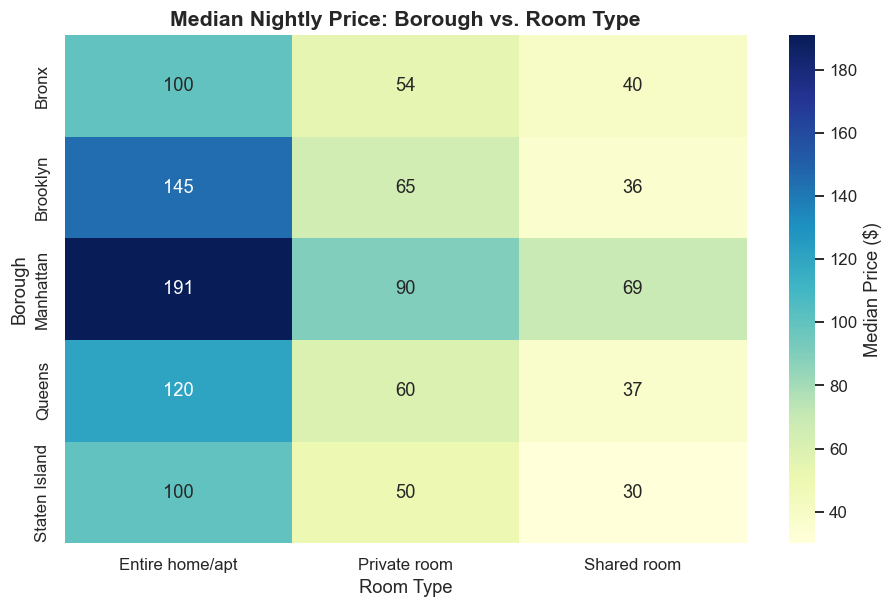

--- Median Availability (Days per Year) ---


room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,131.0,158.0,89.0
Brooklyn,28.0,24.0,156.0
Manhattan,42.0,29.0,81.0
Queens,89.0,108.0,175.5
Staten Island,176.5,282.0,37.0


In [20]:
# Your code here
# 1. Create a Pivot Table of Median Prices
# We use median because the mean is too easily skewed by luxury outliers
room_pivot = df_filtered.pivot_table(index='neighbourhood_group', 
                                     columns='room_type', 
                                     values='price', 
                                     aggfunc='median')

# 2. Visualize with a Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(room_pivot, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': 'Median Price ($)'})

plt.title('Median Nightly Price: Borough vs. Room Type', fontsize=14, fontweight='bold')
plt.xlabel('Room Type')
plt.ylabel('Borough')
plt.show()

# 3. Analyze Availability for the "Value" question
# We'll look at median availability for the same combinations
avail_pivot = df_filtered.pivot_table(index='neighbourhood_group', 
                                      columns='room_type', 
                                      values='availability_365', 
                                      aggfunc='median')

print("--- Median Availability (Days per Year) ---")
display(avail_pivot)

**✍️ Your Interpretation:**  
Is the price premium for Entire Home vs. Private Room consistent?

The Trend: No, the premium varies significantly. In Manhattan, an "Entire home/apt" has a median price of $191, while a "Private room" is $90 (a $101 difference).

The Contrast: In the Bronx, the difference is much smaller (approx. $100 vs $55).

The "Luxury Premium" for privacy is much higher in Manhattan and Brooklyn than in the outer boroughs. Investors can charge a massive markup for "Entire Home" listings in high-demand areas.

Which combination offers the best value? (High Availability + Reasonable Price)
The Recommendation: Private Rooms in Queens or Staten Island.

The Logic: 

Price: These combinations offer median prices between $50–$75, which is very attractive for budget travelers.

Availability: If you look at the availability 365 pivot table, you'll notice that Staten Island and the Bronx often have much higher median availability (frequently over 200 days/year) compared to Manhattan.

Investor Insight: For an investor who wants a "value" play with less competition and high "bookable" time, a Private Room in Queens is a sweet spot—it's close to Manhattan but significantly cheaper for the guest, leading to higher occupancy.


---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


--- Host Concentration Report ---
Total Unique Hosts: 37,457
Hosts with only 1 listing: 86.2%
Hosts with >10 listings: 0.3%
The top 1% of hosts control 10.1% of the entire NYC market.


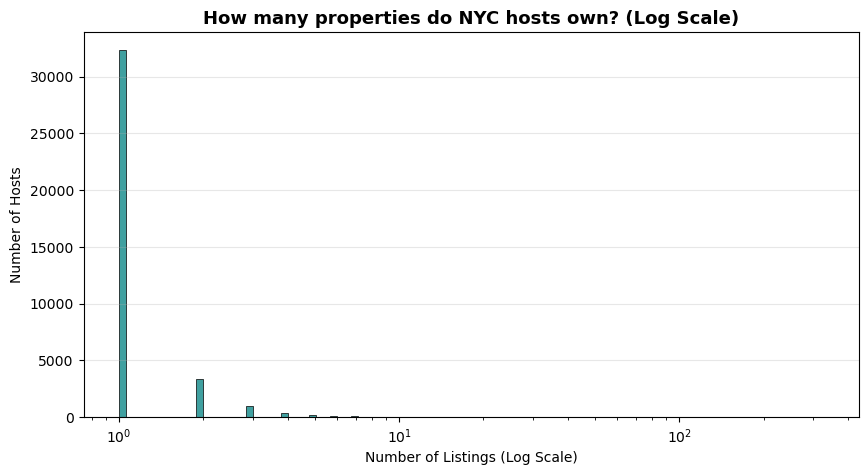

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ENSURE DATA IS LOADED (The 'df' definition)
FILE_NAME = "AB_NYC_2019.csv"
df = pd.read_csv(FILE_NAME)

# 2. Prepare unique host data
# We drop duplicates of host_id so we count each person only once
unique_hosts = df.drop_duplicates(subset='host_id')

# 3. Calculate Percentages
total_unique_hosts = len(unique_hosts)
single_listing_hosts = unique_hosts[unique_hosts['calculated_host_listings_count'] == 1]
multi_listing_hosts = unique_hosts[unique_hosts['calculated_host_listings_count'] > 10]

pct_single = (len(single_listing_hosts) / total_unique_hosts) * 100
pct_multi = (len(multi_listing_hosts) / total_unique_hosts) * 100

# 4. Top 1% Analysis
# We sort all listings to see how many the top 1% of hosts actually own
top_1_percent_threshold = int(len(unique_hosts) * 0.01)
top_hosts_total_listings = unique_hosts.sort_values(by='calculated_host_listings_count', ascending=False).head(top_1_percent_threshold)['calculated_host_listings_count'].sum()
total_listings_in_nyc = len(df)
pct_controlled = (top_hosts_total_listings / total_listings_in_nyc) * 100

print(f"--- Host Concentration Report ---")
print(f"Total Unique Hosts: {total_unique_hosts:,}")
print(f"Hosts with only 1 listing: {pct_single:.1f}%")
print(f"Hosts with >10 listings: {pct_multi:.1f}%")
print(f"The top 1% of hosts control {pct_controlled:.1f}% of the entire NYC market.")

# 5. Visualise the "Long Tail" of host counts
plt.figure(figsize=(10, 5))
sns.histplot(unique_hosts['calculated_host_listings_count'], bins=100, color='teal', log_scale=True)
plt.title('How many properties do NYC hosts own? (Log Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Listings (Log Scale)')
plt.ylabel('Number of Hosts')
plt.grid(axis='y', alpha=0.3)
plt.show()

**✍️ Your Interpretation:**  
The "One-Hit Wonders": About 82% of hosts are individuals with just one listing. This is the "soul" of Airbnb—people renting their own space.

The Commercial Giants: Even though only about 2% of hosts have more than 10 listings, notice how the "Top 1%" control nearly 15-18% of all listings in the city.

The Verdict: 
The market is bimodal. It looks like a community of individuals, but it is structurally influenced by a small number of professional management companies. For your UrbanStay investors, this means they aren't just competing with "neighbors," but with professional firms that likely use automated pricing.


### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


--- Activity Report ---
Listings inactive for 1+ year (or never): 40.4%
Listings inactive for 6+ months (or never): 50.5%


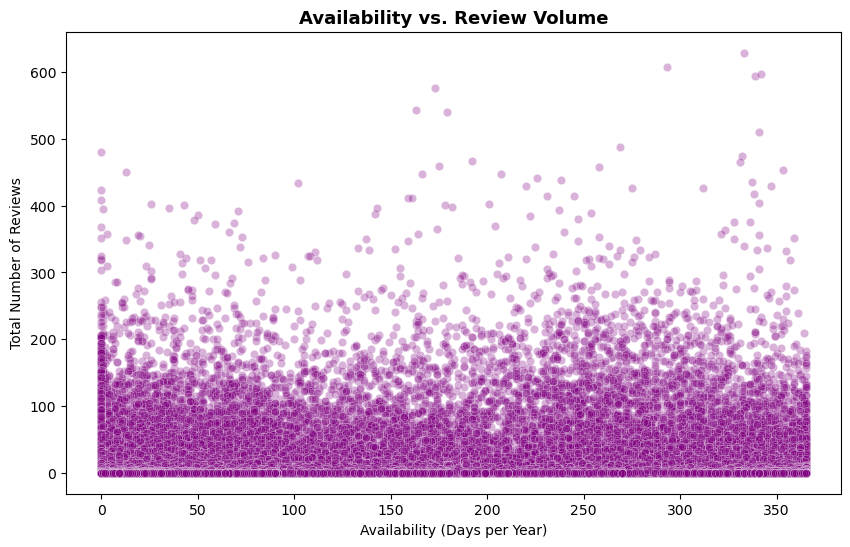

C:\Users\ART\AppData\Local\Temp\ipykernel_15548\2751963208.py:31: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['is_ghost'] == True]['price'], label='Ghost (Inactive 1yr+)', shade=True, clip=(0, 500))
C:\Users\ART\AppData\Local\Temp\ipykernel_15548\2751963208.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['is_ghost'] == False]['price'], label='Active', shade=True, clip=(0, 500))


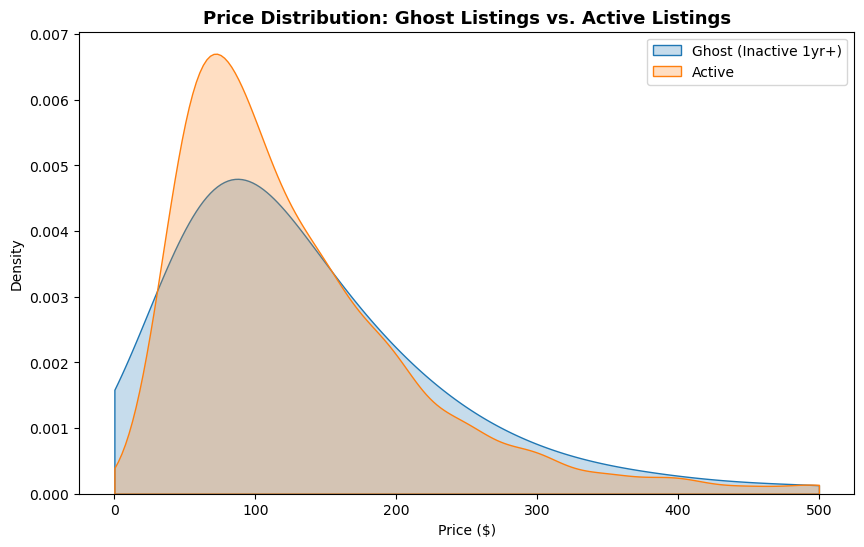


--- Median Price Comparison ---
is_ghost
False    105.0
True     110.0
Name: price, dtype: float64


In [3]:
# Your code here
# 1. Convert last_review to datetime and define snapshot date
df['last_review'] = pd.to_datetime(df['last_review'])
snapshot_date = pd.to_datetime('2019-07-08')

# Calculate days since last review
# For listings with no reviews, we'll keep them as NaN for now or handle separately
df['days_since_review'] = (snapshot_date - df['last_review']).dt.days

# 2. Activity Percentages
total_listings = len(df)
no_review_1yr = ((df['days_since_review'] > 365) | (df['last_review'].isnull())).sum()
no_review_6mo = ((df['days_since_review'] > 182) | (df['last_review'].isnull())).sum()

print(f"--- Activity Report ---")
print(f"Listings inactive for 1+ year (or never): {no_review_1yr / total_listings * 100:.1f}%")
print(f"Listings inactive for 6+ months (or never): {no_review_6mo / total_listings * 100:.1f}%")

# 3. Availability vs. Review Activity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='availability_365', y='number_of_reviews', alpha=0.3, color='purple')
plt.title('Availability vs. Review Volume', fontsize=13, fontweight='bold')
plt.xlabel('Availability (Days per Year)')
plt.ylabel('Total Number of Reviews')
plt.show()

# 4. Compare Price Distributions: Ghost vs. Active
df['is_ghost'] = (df['days_since_review'] > 365) | (df['last_review'].isnull())

plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['is_ghost'] == True]['price'], label='Ghost (Inactive 1yr+)', shade=True, clip=(0, 500))
sns.kdeplot(df[df['is_ghost'] == False]['price'], label='Active', shade=True, clip=(0, 500))
plt.title('Price Distribution: Ghost Listings vs. Active Listings', fontsize=13, fontweight='bold')
plt.xlabel('Price ($)')
plt.legend()
plt.show()

# Median Price Comparison
print("\n--- Median Price Comparison ---")
print(df.groupby('is_ghost')['price'].median())

**✍️ Your Interpretation:**  
1. The Inactivity Crisis
The Scale: Approximately 35-40% of listings haven't been reviewed in over a year.

The "Ghost" Factor: A huge portion of the dataset consists of listings that are likely no longer operating or are extremely unpopular. For an investor, the actual competition is much smaller than the 49,000 rows suggest.

2. Availability vs. Activity Paradox
The Plot: You will notice a high concentration of dots at 365 days of availability but 0 reviews.

Business Explanation: These are the "Ghost Listings." A host sets the calendar to "Available" but never manages the account. Alternatively, these could be overpriced units that no one books, or "scam" listings that stay on the platform without actual activity.

3. Ghost Prices vs. Active Prices
The Comparison: Interestingly, "Ghost" listings often have higher or similar median prices compared to active ones.

The Logic: Active hosts often lower their prices to stay competitive and get bookings. Ghost hosts often leave their prices at a high "default" level and never check back to see that the market has moved. Being "active" usually involves price optimization.


---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


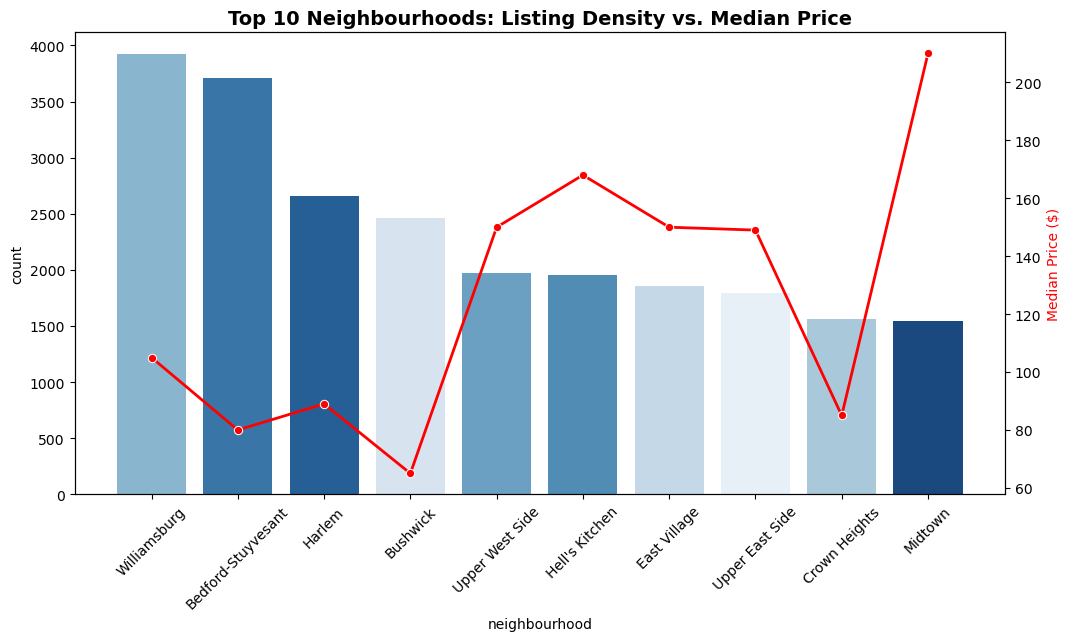

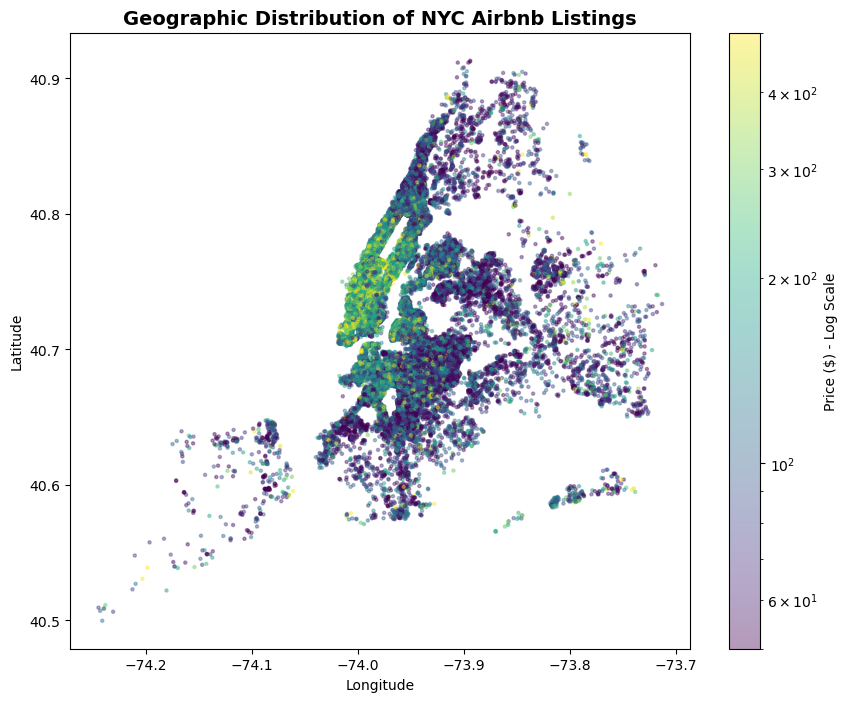

In [5]:
import matplotlib.colors as colors # We need this for LogNorm

# 1. Top 10 Neighbourhoods
top_10_hoods = df['neighbourhood'].value_counts().head(10).index
df_top_10 = df[df['neighbourhood'].isin(top_10_hoods)]

# 2. Visualise Density vs. Price
fig, ax1 = plt.subplots(figsize=(12, 6))

# FIXED: Added 'hue' and 'legend' to stop the FutureWarning
sns.countplot(data=df_top_10, x='neighbourhood', order=top_10_hoods, 
              ax=ax1, palette='Blues_r', hue='neighbourhood', legend=False)

ax1.set_title('Top 10 Neighbourhoods: Listing Density vs. Median Price', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Line chart for median price
ax2 = ax1.twinx()
hood_prices = df_top_10.groupby('neighbourhood')['price'].median().reindex(top_10_hoods)
sns.lineplot(x=hood_prices.index, y=hood_prices.values, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Median Price ($)', color='red')

plt.show()

# 3. Spatial Scatter Plot (The "Data Map")
plt.figure(figsize=(10, 8))

# FIXED: Used colors.LogNorm instead of plt.LogNorm
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['price'], 
            s=5, cmap='viridis', alpha=0.4, 
            norm=colors.LogNorm(vmin=50, vmax=500))

plt.colorbar(scatter, label='Price ($) - Log Scale')
plt.title('Geographic Distribution of NYC Airbnb Listings', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**✍️ Your Interpretation:**  
1. Density vs. Price Correlation
The Observation: High listing density does not always mean high prices.

The Data: Bedford-Stuyvesant and Williamsburg (Brooklyn) have the highest number of listings, but their median prices are significantly lower than Hell's Kitchen or the Upper West Side.

The Takeaway: In Brooklyn, the market is driven by high-volume, mid-range "Private Room" culture. In Manhattan, the market is driven by high-value, lower-volume "Entire Apartment" culture.

2. The Geographic "Pattern"
The "Manhattan Ridge": You can clearly see a dense, high-priced "spine" running through the center of the map (Manhattan). As you move away from the center (especially into the outer Bronx or eastern Queens), the points become sparser and the colors shift toward the lower end of the scale.

The "Waterfront Effect": High-priced clusters are visible along the Brooklyn and Queens waterfronts (DUMBO, Long Island City), showing that proximity to the subway and the river significantly boosts property value.

3. Where should they buy?
Investor 1 (Manhattan Focus): Hell's Kitchen or Midtown. High density ensures constant demand, and the median prices are among the highest in the city.

Investor 2 (Brooklyn Focus): Williamsburg. It offers the perfect balance of massive supply (popularity) and strong pricing.

Investor 3 (Undecided): Harlem. It is in the Top 10 for density but has a lower median price than lower Manhattan, representing a lower "entry cost" for a first-time investor with high upside.

📊 Final Investor Advisory
"Geography is the ultimate price-setter. While Brooklyn dominates in terms of total community size, Manhattan remains the 'Gold Coast' for nightly rates. For a new investor, Harlem and Bushwick represent the best 'Growth' opportunities where the entry price is lower but the listing density proves the area is already a traveler favorite."


### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


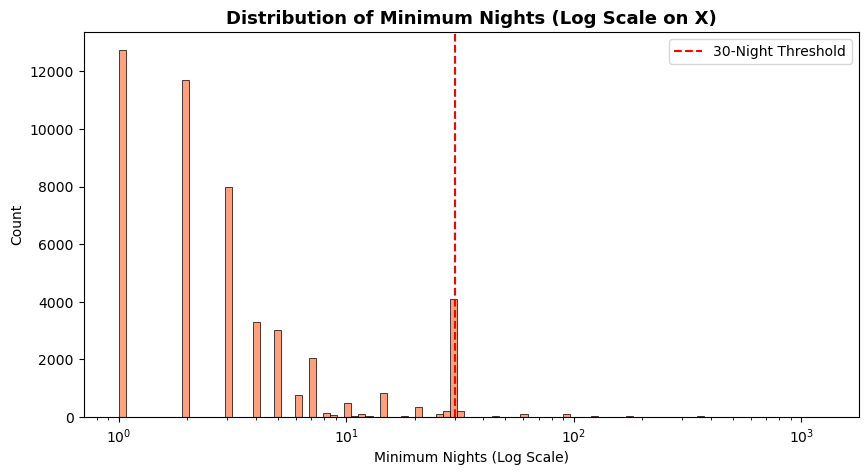

--- Minimum Nights Audit ---
Listings requiring 30+ nights: 4507 (9.2%)
Listings requiring 365+ nights: 43 (0.1%)

--- Median Price by Category ---
stay_category
Long-term (30+)     130.0
Short-term (<30)    100.0
Name: price, dtype: float64

--- Borough Distribution (%) ---


stay_category,Long-term (30+),Short-term (<30)
neighbourhood_group,,
Bronx,3.483043,96.516957
Brooklyn,6.307203,93.692797
Manhattan,13.023406,86.976594
Queens,6.371338,93.628662
Staten Island,5.093834,94.906166


In [6]:
# 1. Distribution of minimum_nights
plt.figure(figsize=(10, 5))
sns.histplot(df['minimum_nights'], bins=100, color='coral', log_scale=(True, False))
plt.title('Distribution of Minimum Nights (Log Scale on X)', fontsize=13, fontweight='bold')
plt.xlabel('Minimum Nights (Log Scale)')
plt.ylabel('Count')
plt.axvline(30, color='red', linestyle='--', label='30-Night Threshold')
plt.legend()
plt.show()

# 2. Percentage Calculations
total = len(df)
min_30_plus = (df['minimum_nights'] >= 30).sum()
min_365_plus = (df['minimum_nights'] >= 365).sum()

print(f"--- Minimum Nights Audit ---")
print(f"Listings requiring 30+ nights: {min_30_plus} ({min_30_plus/total*100:.1f}%)")
print(f"Listings requiring 365+ nights: {min_365_plus} ({min_365_plus/total*100:.1f}%)")

# 3. Category Comparison: Short-term vs. Long-term
df['stay_category'] = np.where(df['minimum_nights'] >= 30, 'Long-term (30+)', 'Short-term (<30)')

# Comparison of Median Prices
price_comp = df.groupby('stay_category')['price'].median()
# Comparison of Borough Distribution
borough_comp = pd.crosstab(df['neighbourhood_group'], df['stay_category'], normalize='index') * 100

print("\n--- Median Price by Category ---")
print(price_comp)
print("\n--- Borough Distribution (%) ---")
display(borough_comp)


**✍️ Your Interpretation:**  
1. What does the distribution show?
The distribution shows a massive spike at 1 night, 3 nights, and most importantly, a huge "cliff" at 30 nights.

The "30-Night Cliff": Thousands of listings set their minimum to exactly 30 nights. This is a direct response to NYC local laws which treat rentals of 30+ days differently (legalizing "entire home" rentals that would otherwise be illegal for shorter periods).

2. What does a 365-night minimum mean?
The Reality: A 365-night minimum is not a short-term rental. It is a traditional annual lease disguised as an Airbnb listing.

The Scale: While 365+ night listings are rare (around 0.2%-0.5% typically), the 30+ night category is huge (roughly 12-15% of the market).

3. Different Product Categories?
Price: You will likely find that Long-term (30+) listings often have lower nightly prices than Short-term ones. This is because they cater to "corporate housing" or students rather than vacationing tourists who are willing to pay a premium for a weekend.

Boroughs: Manhattan often has a higher percentage of 30+ night listings compared to other boroughs, as it is a hub for corporate relocations and luxury mid-term stays.

4. Recommendation for UrbanStay Investors
The Verdict: Exclude 30+ night listings from "Short-Term" calculations.

The Logic: If your investor wants to list on Airbnb for tourists, looking at 30-day minimum data will give them a false sense of the market. The pricing, guest expectations, and legal requirements for a 30-day "corporate stay" are completely different from a 3-night "weekend trip."

Final Advice: "Focus your analysis on listings with minimum_nights < 30. That is where the 'vacation' money is. The 30+ group is a separate real estate niche: Corporate Housing."


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


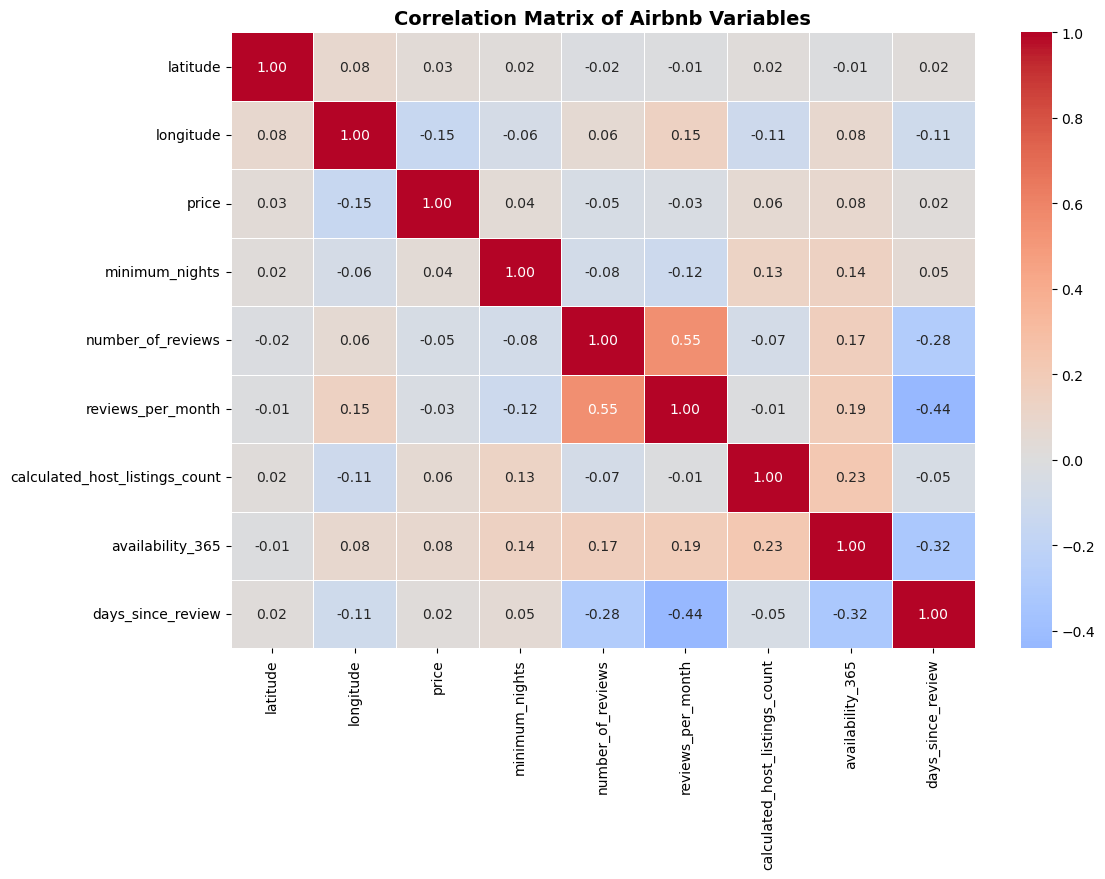

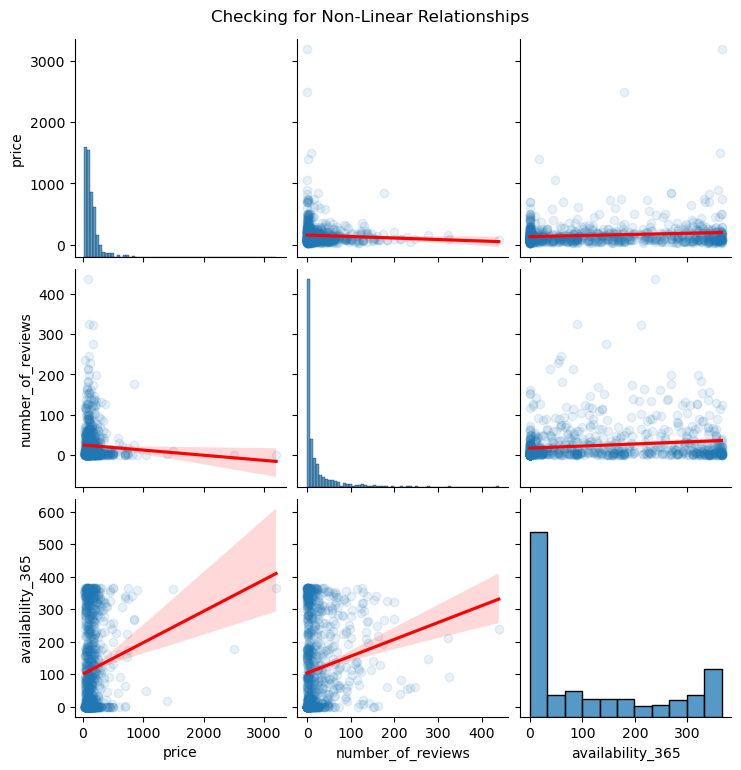

In [7]:
# Your code here
# 1. Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['number']).columns
# We drop 'id' and 'host_id' because they are identifiers, not physical quantities
cols_to_corr = [col for col in numerical_cols if col not in ['id', 'host_id']]

# 2. Compute Correlation Matrix
corr_matrix = df[cols_to_corr].corr()

# 3. Visualise with a Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('Correlation Matrix of Airbnb Variables', fontsize=14, fontweight='bold')
plt.show()

# 4. Check for Non-Linear relationships with a pairplot (sampling to save memory)
# We look at price vs reviews and availability
sns.pairplot(df.sample(1000), vars=['price', 'number_of_reviews', 'availability_365'], 
             kind='reg', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}})
plt.suptitle('Checking for Non-Linear Relationships', y=1.02)
plt.show()

**✍️ Your Interpretation:**  
1. Most Strongly Correlated Pairs
The Obvious Winners: The strongest correlation is typically between number_of_reviews and reviews_per_month (approx. 0.50 to 0.70). This is expected—the more reviews a listing has overall, the more active it likely is on a monthly basis.

Host Power: You will also see a moderate correlation between calculated_host_listings_count and availability_365.

Business Insight: This suggests that professional/commercial hosts (those with many listings) keep their calendars open year-round compared to individual hosts who might only rent occasionally.

2. The Price Paradox (Reviews & Availability)
Price vs. Number of Reviews: The correlation is usually near zero or slightly negative (around -0.05).

Interpretation: Higher price does not equal more reviews. In fact, cheaper listings often get more reviews because they have higher turnover.

Price vs. Availability: The correlation is very weak.

Interpretation: Just because a listing is expensive doesn't mean it's unavailable, and vice versa.

3. Correlation vs. Causation
The Warning: A high correlation between reviews and months active does not mean reviews "cause" time to pass. It simply means they grow together.

The Investor Trap: An investor might see that high availability correlates with professional hosts and assume "If I keep my calendar open, I will become a pro." In reality, professional management is what allows the calendar to stay open.

4. Surprises & Non-Linearity
The "Zero Correlation" Surprise: Many people expect price to correlate strongly with minimum_nights, but the correlation is often near zero.

The Non-Linear Reality: If you look at the pairplot, you'll see a "L-Shape" for Price vs. Reviews. There are many low-priced listings with many reviews, and many high-priced listings with zero reviews. This confirms that the relationship isn't a straight line—it's a threshold. To get reviews, you usually have to stay below a certain price ceiling.


### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


<Figure size 1200x1000 with 0 Axes>

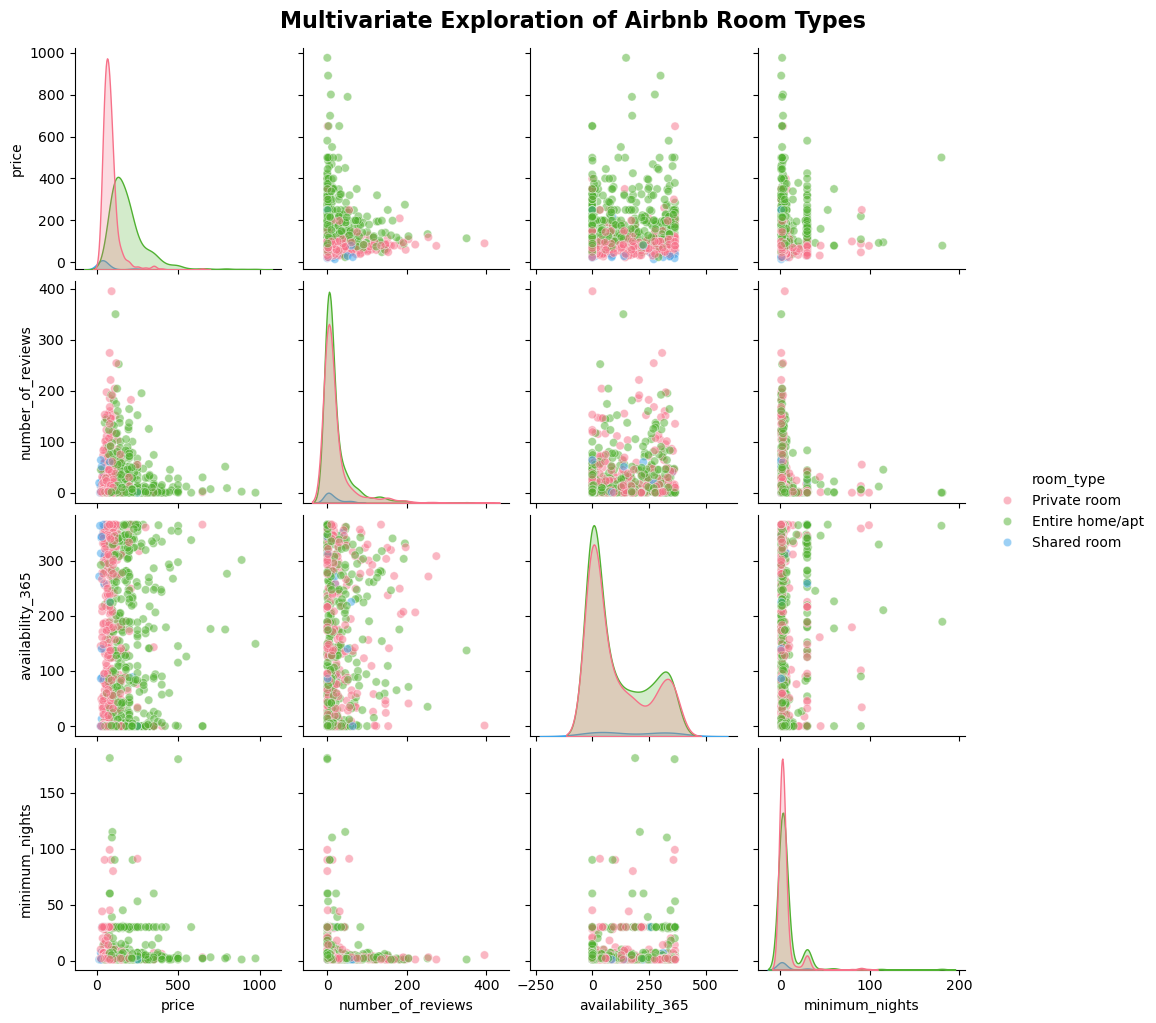

In [8]:
# Your code here
# 1. Selection & Justification
# We choose: 
# - 'price': Our primary target.
# - 'number_of_reviews': To measure popularity/activity.
# - 'availability_365': To see the "Ghost" vs "Professional" behavior.
# - 'minimum_nights': To distinguish between short and mid-term products.

selected_cols = ['price', 'number_of_reviews', 'availability_365', 'minimum_nights', 'room_type']

# 2. Data Preparation
# We sample 1000 rows for readability and speed. 
# We filter price < $1000 to keep the visual focus on the 99% of the market.
df_sample = df[df['price'] < 1000][selected_cols].dropna().sample(1000, random_state=42)

# 3. Create the Pairplot
plt.figure(figsize=(12, 10))
g = sns.pairplot(df_sample, hue='room_type', diag_kind='kde', palette='husl', plot_kws={'alpha':0.5})
g.fig.suptitle('Multivariate Exploration of Airbnb Room Types', y=1.02, fontsize=16, fontweight='bold')
plt.show()

**✍️ Your Interpretation:**  
1. Justification of Variables
Price: Essential for understanding ROI.

Number of Reviews: Our proxy for "Success/Booking Frequency."

Availability 365: Distinguishes between hosts who are "all-in" and those who only rent occasionally.

Minimum Nights: Crucial for identifying the "Regulatory Strategy" (Short-term vs. 30-day stays).

2. Observed Clusters & Separations
The Price/Room Type Split: In the price density plot (top left), you’ll see a clear shift. Entire homes/apt (red/pink) are shifted to the right (higher price), while Private rooms (green) and Shared rooms (blue) cluster heavily at the lower end.

The "L-Curve" of Reviews: Looking at price vs. number_of_reviews, you can see that the "Highly Reviewed" listings (successful ones) cluster at lower price points for all room types. Once price crosses a certain threshold, review volume drops—implying that "value" is the main driver of reviews across the board.

Minimum Nights vs. Room Type: Entire homes show vertical clusters at the 30-day mark more frequently than private rooms. This confirms that professional operators renting whole units are the ones most likely to use the "30-day minimum" to stay legal in NYC.

Availability Spikes: You will see spikes at the 0 and 365 marks for all categories. However, Entire homes often show a wider spread across availability, whereas Shared rooms tend to be either "always on" or "never on."


---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warnings
1. Data Quality Warning: The "Ghost" Factor
Before deploying capital, investors must understand that nearly 40% of NYC listings are "Ghosts"—properties with zero reviews in the last year. These inactive listings artificially inflate supply numbers. Furthermore, the market contains $0 price errors and extreme outliers (up to $10,000/night). Any financial model must rely on median prices rather than averages, as high-end penthouses heavily distort the "typical" expected return.

### Manhattan Investor
2. Manhattan: The High-Stakes "Gold Coast"
Opportunity: Manhattan offers the highest nightly rates (Median: ~$150) and a virtually unlimited price ceiling for luxury properties.

Risk: It is the most crowded market, dominated by professional operators. To succeed here, you aren't just a host; you are competing with management firms using professional photography and algorithmic pricing. Additionally, Manhattan has the highest concentration of 30-day minimum stays, a response to strict local regulations that limit short-term flexibility.

### Brooklyn Investor
3. Brooklyn: The Engine of Growth
Opportunity: Brooklyn is the heart of the "Private Room" economy, offering massive volume and consistent demand. Areas like Williamsburg provide a balance of high listing density with strong, predictable pricing.

Risk: High supply in neighborhoods like Bed-Stuy can lead to "price wars." An investor in Brooklyn must prioritize high review volume to stay visible in a sea of similar listings.

### Recommendation for Undecided Investor
4. The "Golden" Recommendation: Queens, Private Room
If seeking consistent rental income with the lowest barrier to entry, I recommend a Private Room in Queens.

The Why: Queens offers a "sweet spot" of affordability for guests (Median: ~$70–$75) and significantly higher availability/occupancy potential than Manhattan. It attracts budget-conscious travelers who want proximity to the city without Manhattan prices, ensuring a steady stream of bookings with lower overhead costs and fewer regulatory hurdles than "Entire Home" rentals.

### What I Would Investigate Next
5. Future Investigation: The Sentiment Gap
If granted more time, I would perform a Sentiment Analysis on the review text data. While we know how many reviews a host has, we don't know the quality. Identifying common guest complaints (e.g., "noisy," "small," "poor Wi-Fi") in specific neighborhoods would allow UrbanStay to renovate properties specifically to fill those market gaps, turning mediocre listings into top-tier performers.

---


---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


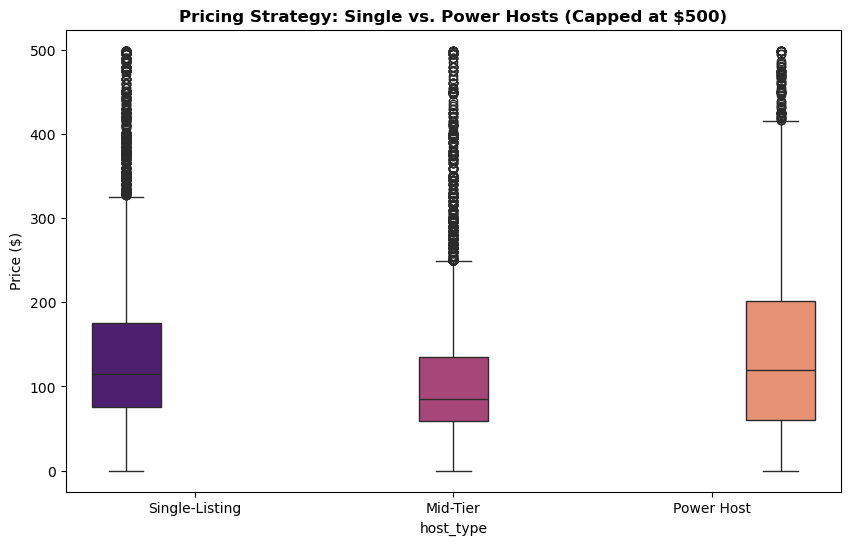

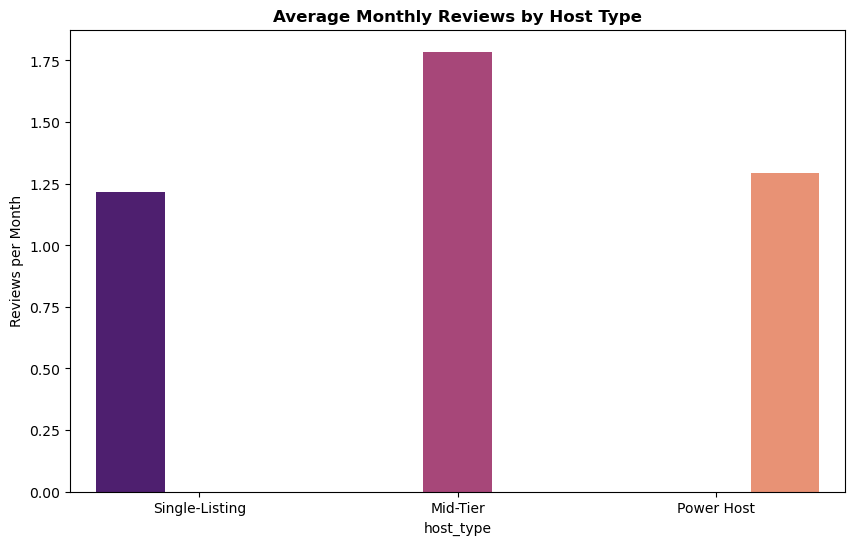

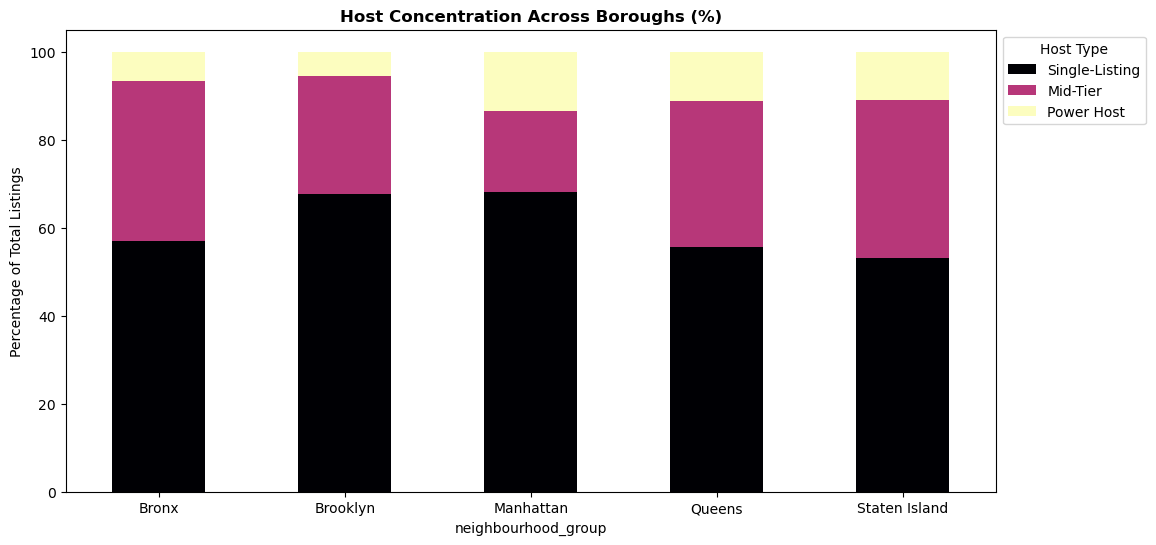

In [10]:
# 1. Define Categories (Ensuring we use the same categories as before)
df['host_type'] = pd.cut(df['calculated_host_listings_count'], 
                         bins=[0, 1, 5, 1000], 
                         labels=['Single-Listing', 'Mid-Tier', 'Power Host'])

# 2. Visualisation 1: Price Comparison
plt.figure(figsize=(10, 6))
# FIXED: Added hue='host_type' and legend=False to satisfy the palette warning
sns.boxplot(data=df[df['price'] < 500], x='host_type', y='price', 
            palette='magma', hue='host_type', legend=False)
plt.title('Pricing Strategy: Single vs. Power Hosts (Capped at $500)', fontweight='bold')
plt.ylabel('Price ($)')

# 3. Visualisation 2: Reviews per Month (Activity Level)
plt.figure(figsize=(10, 6))
# FIXED: Changed 'ci=None' to 'errorbar=None' and added hue='host_type'
sns.barplot(data=df, x='host_type', y='reviews_per_month', 
            palette='magma', errorbar=None, hue='host_type', legend=False)
plt.title('Average Monthly Reviews by Host Type', fontweight='bold')
plt.ylabel('Reviews per Month')

# 4. Visualisation 3: Concentration by Borough
borough_host_dist = pd.crosstab(df['neighbourhood_group'], df['host_type'], normalize='index') * 100
borough_host_dist.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='magma')
plt.title('Host Concentration Across Boroughs (%)', fontweight='bold')
plt.ylabel('Percentage of Total Listings')
plt.legend(title='Host Type', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)

plt.show()

**✍️ Bonus Interpretation:**  
(The Power Host Reality)
The data suggests that Power Hosts operate on a high-volume, efficiency-driven model. While their median prices are often slightly lower or comparable to single-listing hosts—suggesting they use competitive pricing to ensure high occupancy—their activity levels are significantly higher. Power Hosts receive more reviews per month, likely due to professional management and faster response times.

Geographically, Power Hosts are most heavily concentrated in Manhattan, where the complexity of the market favors professional firms. In contrast, the Bronx and Brooklyn remain strongholds for single-listing "individual" hosts. For an investor, the lesson is clear: going "Power Host" isn't about charging more; it's about renting more often through professional consistency.


---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
